In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Refrence : https://archive.ics.uci.edu/ml/datasets/Heart+Disease 

# Exploratory Data Analysis (EDA) and visualization

In [2]:
df= pd.read_csv('heart.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [3]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [4]:
# binery class logestic regression
df['target'].unique()

array([1, 0])

In [5]:
df['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [6]:
# balance data set?
165/303

0.5445544554455446

<Axes: xlabel='target', ylabel='count'>

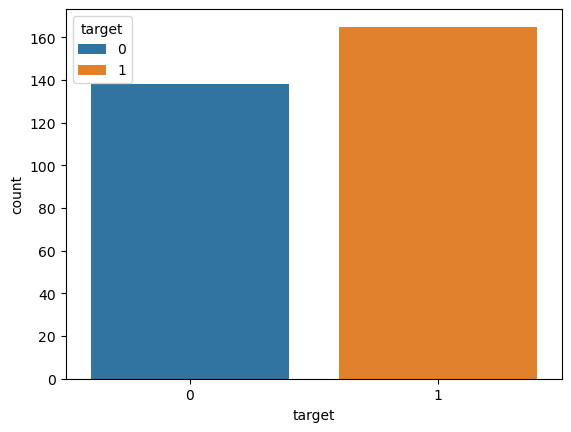

In [7]:
sns.countplot(x=df['target'] , hue=df['target'])

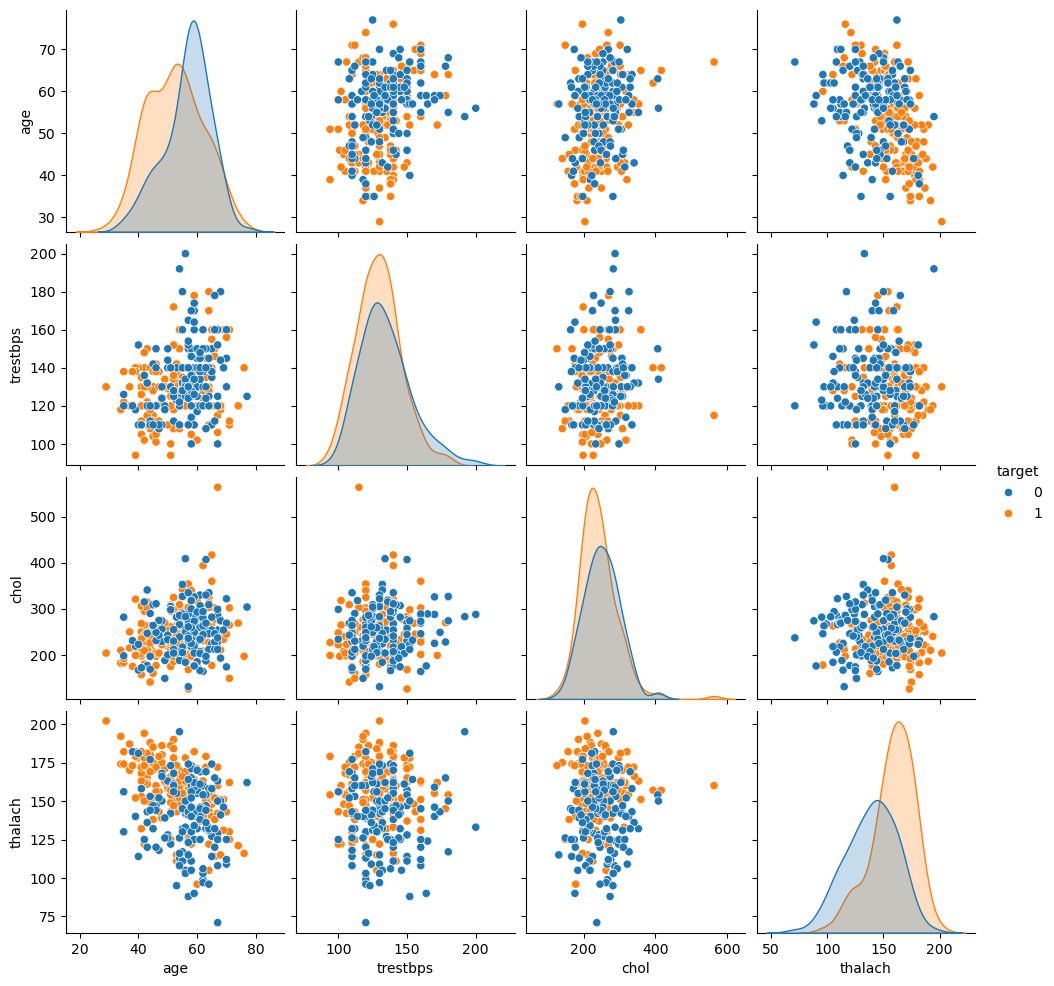

In [8]:
sns.pairplot(data=df[['age' , 'trestbps' , 'chol' , 'thalach' , 'target']] , hue='target')

<Axes: >

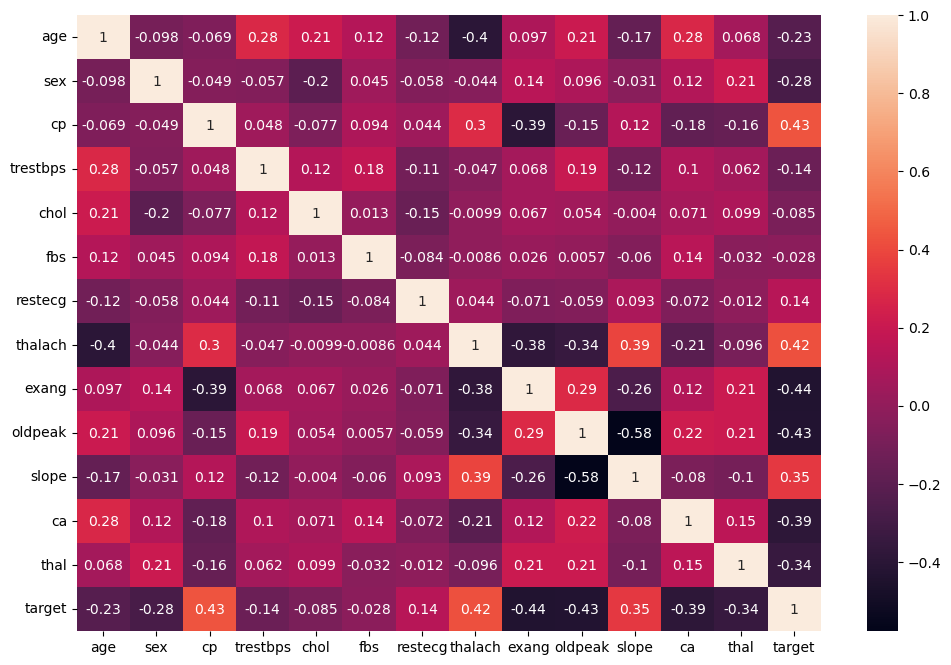

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),  annot=True)

# train _ test split

In [3]:
X=df.drop('target' , axis=1)
y=df['target']

from sklearn.model_selection import train_test_split
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=101)
X_train , X_val , y_train , y_val=train_test_split(X_train_full , y_train_full , test_size=0.2 , random_state=101)

from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
X_train=scale.fit_transform(X_train)
X_test=scale.transform(X_test)
X_val=scale.transform(X_val)

# logestic regression cv model

In [4]:
from sklearn.linear_model import LogisticRegressionCV
log_model=LogisticRegressionCV( cv=10  , max_iter=5000000)

In [5]:
log_model.fit(X_train , y_train)

C:\Users\Ziba\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
C:\Users\Ziba\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass se

In [6]:
log_model.C_

array([0.04641589])

In [14]:
log_model.get_params()

{'Cs': 10,
 'class_weight': None,
 'cv': 10,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1.0,
 'l1_ratios': 'warn',
 'max_iter': 5000000,
 'n_jobs': None,
 'penalty': 'deprecated',
 'random_state': None,
 'refit': True,
 'scoring': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'use_legacy_attributes': 'warn',
 'verbose': 0}

In [15]:
log_model.coef_

array([[-0.07863596, -0.66551595,  0.82587973, -0.23717155, -0.18260785,
         0.0439636 ,  0.1131254 ,  0.40656729, -0.41419257, -0.49672171,
         0.35446589, -0.78401967, -0.54014178]])

In [16]:
coefs=pd.Series(index=X.columns , data=log_model.coef_[0])
coefs

age        -0.078636
sex        -0.665516
cp          0.825880
trestbps   -0.237172
chol       -0.182608
fbs         0.043964
restecg     0.113125
thalach     0.406567
exang      -0.414193
oldpeak    -0.496722
slope       0.354466
ca         -0.784020
thal       -0.540142
dtype: float64

In [17]:
coefs=coefs.sort_values()
coefs

ca         -0.784020
sex        -0.665516
thal       -0.540142
oldpeak    -0.496722
exang      -0.414193
trestbps   -0.237172
chol       -0.182608
age        -0.078636
fbs         0.043964
restecg     0.113125
slope       0.354466
thalach     0.406567
cp          0.825880
dtype: float64

<Axes: xlabel='None'>

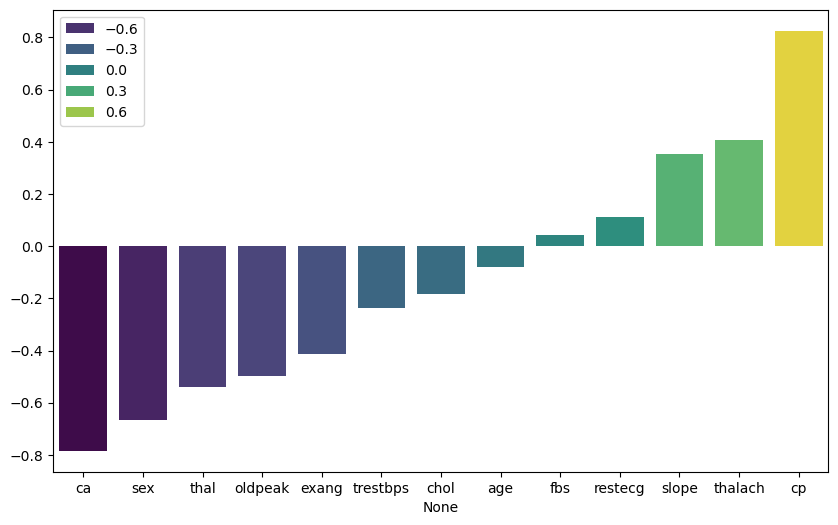

In [18]:
plt.figure(figsize=(10,6))
sns.barplot(x=coefs.index , y=coefs.values , palette='viridis' , hue=coefs.values)

# Evaluating of model

In [7]:
from sklearn.metrics import classification_report , ConfusionMatrixDisplay , f1_score

# Decision threshold tuning

In [9]:
y_proba=log_model.predict_proba(X_val)[:,1]
treshold=np.linspace(0,1,200)
f_score=[]
for t in treshold:
    y_val_pred=(y_proba>=t).astype(int)
    f_score.append(f1_score(y_val,y_val_pred))

best_treshold=treshold[np.argmax(f_score)]
print('best threshold is:' , best_treshold)

best threshold is: 0.6934673366834171


In [10]:
y_test_proba=log_model.predict_proba(X_test)[:,1]
y_pred=(y_test_proba>=best_treshold).astype(int)

In [18]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.79      0.84      0.81        31
           1       0.82      0.77      0.79        30

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



In [8]:
y_prediction=log_model.predict(X_test)
print(classification_report(y_test , y_prediction))

              precision    recall  f1-score   support

           0       0.95      0.68      0.79        31
           1       0.74      0.97      0.84        30

    accuracy                           0.82        61
   macro avg       0.85      0.82      0.82        61
weighted avg       0.85      0.82      0.82        61



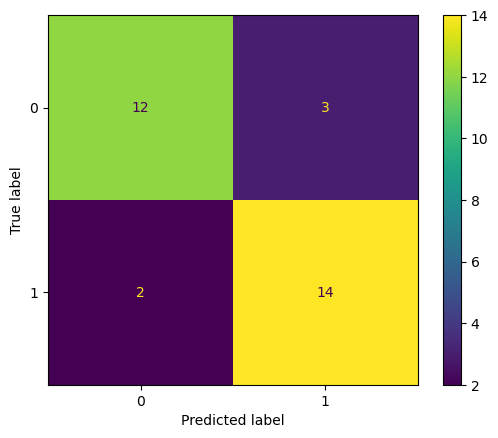

In [223]:
ConfusionMatrixDisplay.from_predictions(y_test , y_pred)

In [9]:
help(LogisticRegressionCV)

Help on class LogisticRegressionCV in module sklearn.linear_model._logistic:

class LogisticRegressionCV(LogisticRegression, sklearn.linear_model._base.LinearClassifierMixin, sklearn.base.BaseEstimator)
 |  LogisticRegressionCV(*, Cs=10, fit_intercept=True, cv=None, dual=False, penalty='l2', scoring=None, solver='lbfgs', tol=0.0001, max_iter=100, class_weight=None, n_jobs=None, verbose=0, refit=True, intercept_scaling=1.0, multi_class='auto', random_state=None, l1_ratios=None)
 |
 |  Logistic Regression CV (aka logit, MaxEnt) classifier.
 |
 |  See glossary entry for :term:`cross-validation estimator`.
 |
 |  This class implements logistic regression using liblinear, newton-cg, sag
 |  of lbfgs optimizer. The newton-cg, sag and lbfgs solvers support only L2
 |  regularization with primal formulation. The liblinear solver supports both
 |  L1 and L2 regularization, with a dual formulation only for the L2 penalty.
 |  Elastic-Net penalty is only supported by the saga solver.
 |
 |  For t

In [71]:
from sklearn.metrics import RocCurveDisplay , PrecisionRecallDisplay

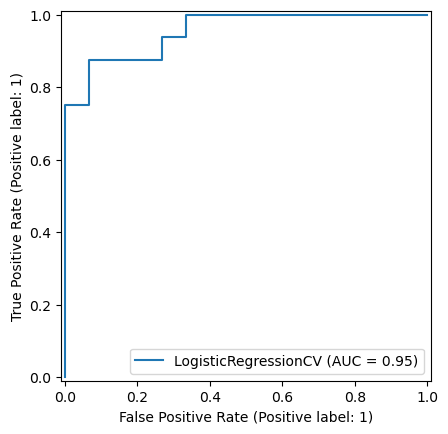

In [225]:
RocCurveDisplay.from_estimator(log_model, X_test , y_test )

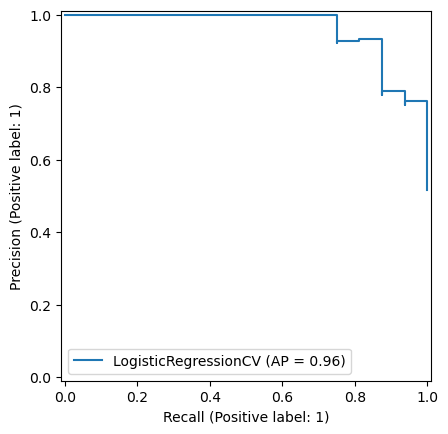

In [227]:
PrecisionRecallDisplay.from_estimator(log_model , X_test , y_test)

In [229]:
patient = [[ 54. , 1. , 0. , 122. , 286. , 0. , 0. , 116. , 1. ,
 3.2, 1. , 2. , 2. ]]

In [231]:
log_model.predict(patient)

array([0], dtype=int64)

In [233]:
scaled_patient=scale.transform(patient)
log_model.predict(scaled_patient)

C:\Users\Ziba\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0], dtype=int64)